In [1]:
import sys

import polars as pl
import torch


from modeling_module.data_loader.MultiPartDataModule import MultiPartDataModule
from modeling_module.utils.checkpoint import save_model_dict, load_model_dict

'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR

save_dir = DIR + 'fit/20251109_LTB'


True
1
12.8
2.9.0.dev20250716+cu128
NVIDIA GeForce RTX 5080
2.9.0.dev20250716+cu128


In [2]:
target_dyn_demand_monthly = pl.read_parquet(DIR + 'target_dyn_demand_monthly.parquet').sort(['oper_part_no', 'demand_dt'])
target_dyn_demand_monthly = (target_dyn_demand_monthly.group_by('oper_part_no', maintain_order = True).map_groups(lambda g: g.with_columns(pl.arange(1, len(g) + 1).alias('seq'))))

filtered_target = target_dyn_demand_monthly.group_by('oper_part_no').agg(pl.col('seq').max().alias('seq_max')).filter(pl.col('seq_max') > 43).select('oper_part_no') # seq Q75

target_dyn_demand_monthly = target_dyn_demand_monthly.join(filtered_target, on = 'oper_part_no', how = 'right').select(['oper_part_no', 'demand_dt', 'demand_qty'])
target_dyn_demand_monthly


oper_part_no,demand_dt,demand_qty
str,i64,f64
"""85726-7206-0""",201801,11.0
"""85726-7206-0""",201802,6.0
"""85726-7206-0""",201803,15.0
"""85726-7206-0""",201804,4.0
"""85726-7206-0""",201805,9.0
…,…,…
"""U3215-16211""",202608,5.0
"""U3215-16211""",202609,5.0
"""U3215-16211""",202610,6.0


In [3]:
plan_yyyymm = 201801
lookback = 36
horizon = 48

data_module = MultiPartDataModule(
    target_dyn_demand_monthly,
    lookback = lookback,
    horizon = horizon,
    batch_size = 64,
    val_ratio = 0.2,
    is_running = False
)
train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

In [4]:
from modeling_module.training.model_trainers.total_train import run_total_train_monthly

model_dict = run_total_train_monthly(train_loader, val_loader, lookback = lookback, horizon = horizon)

revin_use_std: False
revin_subtract_last True
final_clamp_nonneg True
Titan Base (Monthly)

[train_titan] ===== Stage 1/2 =====
  - spike: OFF
  - epochs: 20 | lr=0.0003 | horizon_decay=False
[train_titan] Effective TrainingConfig:
{
  "device": "cuda",
  "lookback": 36,
  "horizon": 48,
  "epochs": 20,
  "lr": 0.0003,
  "weight_decay": 0.001,
  "t_max": 40,
  "patience": 100,
  "max_grad_norm": 30.0,
  "amp_device": "cuda",
  "loss_mode": "point",
  "point_loss": "huber",
  "huber_delta": 0.8,
  "q_star": 0.5,
  "use_cost_q_star": false,
  "Cu": 1.0,
  "Co": 1.0,
  "quantiles": [
    0.1,
    0.5,
    0.9
  ],
  "use_intermittent": true,
  "alpha_zero": 3.0,
  "alpha_pos": 1.0,
  "gamma_run": 0.3,
  "cap": null,
  "use_horizon_decay": false,
  "tau_h": 0.85,
  "val_use_weights": false,
  "spike_loss": {
    "enabled": false,
    "strategy": "mix",
    "huber_delta": 0.6,
    "asym_up_weight": 1.0,
    "asym_down_weight": 8.0,
    "mad_k": 1.5,
    "w_spike": 32.0,
    "w_norm": 1.0,
 

In [5]:
from modeling_module.models.Titan.common.configs import TitanConfig
from modeling_module.utils.exogenous_utils import calendar_sin_cos
from modeling_module.models.PatchTST.common.configs import PatchTSTConfigMonthly
from modeling_module.models.PatchMixer.common.configs import PatchMixerConfigMonthly, PatchMixerConfig

save_dir = DIR + 'fit'
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

pm_base_config = PatchMixerConfig(
        lookback = lookback,
        horizon = horizon,
        device = device,
        loss_mode = 'point',
        point_loss = 'mae'
    )

pm_quantile_config = PatchMixerConfig(
    lookback = lookback,
    horizon = horizon,
    device = device,
    loss_mode = 'quantile',
    quantiles = (0.1, 0.5, 0.9)
)
ti_config = TitanConfig(
        lookback=lookback,
        horizon=horizon,
        input_dim=1,
        d_model=256,
        n_layers=3,
        n_heads=4,
        d_ff=512,
        dropout=0.1,
        contextual_mem_size=256,
        persistent_mem_size=64,
        use_exogenous=True, exo_dim=2,     # month sin/cos
        final_clamp_nonneg=True,
    )

pt_config = PatchTSTConfigMonthly(
        device = device,
        loss_mode = 'auto',
        quantiles = (0.1, 0.5, 0.9)
    )

cfg_map = {
    # "PatchMixer Base": pm_base_config,
    # "PatchMixer Quantile": pm_quantile_config,
    "Titan Base": ti_config,
    "Titan LMM": ti_config,
    "Titan Seq2Seq": ti_config,
    # "PatchTST Base": pt_config,
    # "PatchTST Quantile": pt_config
}



In [6]:

save_dir = DIR + 'fit/20251110_LTB'

models_only = {
    name: (pack["model"] if isinstance(pack, dict) and "model" in pack else pack)
    for name, pack in model_dict.items()
}

# cfg_by_name도 맞춰서 준비(필요하면)
cfg_by_name = {
    name: (pack.get("cfg") if isinstance(pack, dict) else None)
    for name, pack in model_dict.items()
}

builder_key_by_name = {
  # "PatchMixer Base": "patchmixer_base",
  # "PatchMixer Quantile": "patchmixer_quantile",
  "Titan Base": "titan_base",
  "Titan LMM": "titan_lmm",
  "Titan Seq2Seq": "titan_seq2seq",
  # "PatchTST Base": "patchtst_base",
  # "PatchTST Quantile": "patchtst_quantile",
}
save_index = save_model_dict(
    models_only,
    save_dir,
    cfg_by_name = cfg_by_name,
    builder_key_by_name=builder_key_by_name)



In [7]:
# Load
from modeling_module.models.model_builder import (
    build_patch_mixer_quantile,
    build_patchTST_base, build_patchTST_quantile, build_patch_mixer_base, build_titan_base, build_titan_lmm,
    build_titan_seq2seq,
)

builders = {
    # "patchmixer_base": lambda cfg: build_patch_mixer_base(cfg or PatchMixerConfig()),
    # "patchmixer_quantile": lambda cfg: build_patch_mixer_quantile(cfg or PatchMixerConfig()),
    "titan_base": lambda cfg: build_titan_base(cfg or TitanConfig()),
    "titan_lmm": lambda cfg: build_titan_lmm(cfg or TitanConfig()),
    "titan_seq2seq": lambda cfg: build_titan_seq2seq(cfg or TitanConfig()),
    # "patchtst_base": lambda cfg: build_patchTST_base(cfg or PatchTSTConfigMonthly()),
    # "patchtst_quantile": lambda cfg: build_patchTST_quantile(cfg or PatchTSTConfigMonthly()),
}
loaded = load_model_dict(save_dir, builders, device = device)


[load] titan_base ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251110_LTB\titan_base.pt
revin_use_std: False
revin_subtract_last True
final_clamp_nonneg True
[warn] TitanBaseModel: strict load failed → attempting adaptive remap
[load partial] titan_base: non-critical mismatch → partial load.
[load] titan_lmm ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251110_LTB\titan_lmm.pt
[warn] TitanLMMModel: strict load failed → attempting adaptive remap
[load partial] titan_lmm: non-critical mismatch → partial load.
[load] titan_seq2seq ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251110_LTB\titan_seq2seq.pt
[warn] TitanSeq2SeqModel: strict load failed → attempting adaptive remap
[load partial] titan_seq2seq: non-critical mismatch → partial load.


[FCAST-DBG] DMS block: Hm=27, var(Hm)=7.58399, first5=[104.216, 105.538, 107.601, 110.731, 109.672]
[FCAST-DBG] DONE: H=120, var=1.04871e+06, first5=[104.216, 105.538, 107.601, 110.731, 109.672]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=11.5117, first5=[40.373, 42.351, 44.0497, 43.5984, 42.5909]
[FCAST-DBG] DONE: H=120, var=1.16373e+07, first5=[40.373, 42.351, 44.0497, 43.5984, 42.5909]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=16.7283, first5=[30.0876, 30.1859, 32.3022, 34.0943, 38.4373]
[FCAST-DBG] DONE: H=120, var=1.14468e+08, first5=[30.0876, 30.1859, 32.3022, 34.0943, 38.4373]
dict_items([('titan_base', array([ 104.21553 ,  105.537605,  107.60127 ,  110.73085 ,  109.67237 ,
        106.00923 ,  102.63036 ,  114.22921 ,  114.94793 ,  111.362495,
        108.79782 ,  108.960655,  109.63673 ,  108.64798 ,  107.04849 ,
        105.89987 ,  106.01461 ,  105.83802 ,  106.39103 ,  106.87207 ,
        109.98755 ,  110.779854,  108.95899 ,  108.733   ,  109.377846,
        108.56555 ,  107.432816,

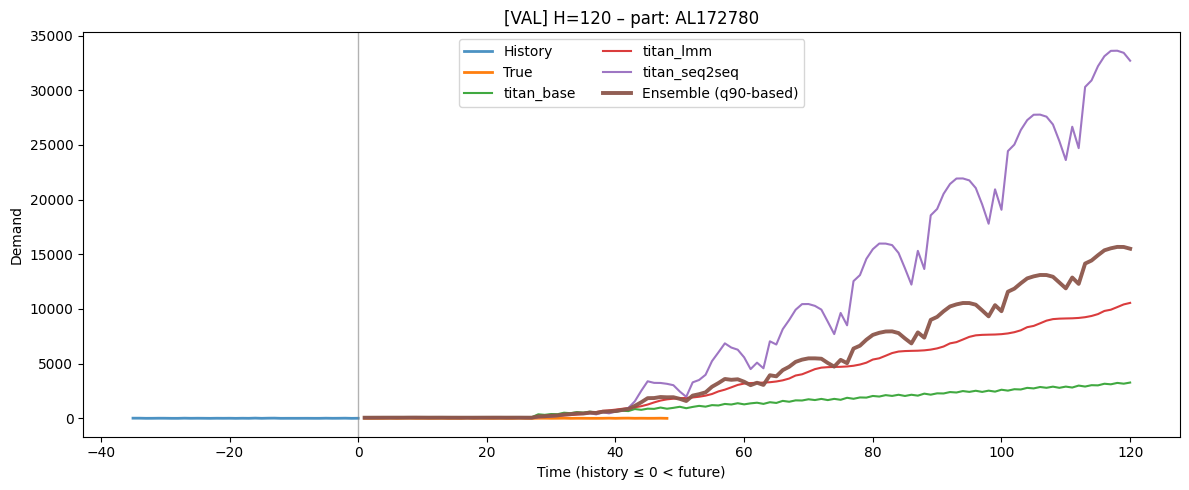

[FCAST-DBG] DMS block: Hm=27, var(Hm)=7.99258, first5=[110.618, 112.149, 114.462, 117.819, 116.879]
[FCAST-DBG] DONE: H=120, var=1.0414e+06, first5=[110.618, 112.149, 114.462, 117.819, 116.879]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=11.9872, first5=[44.4241, 46.4774, 48.3311, 47.8337, 46.7487]
[FCAST-DBG] DONE: H=120, var=1.15615e+07, first5=[44.4241, 46.4774, 48.3311, 47.8337, 46.7487]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=16.7681, first5=[35.164, 35.2544, 37.3299, 39.1033, 43.3776]
[FCAST-DBG] DONE: H=120, var=1.33358e+08, first5=[35.164, 35.2544, 37.3299, 39.1033, 43.3776]
dict_items([('titan_base', array([ 110.618126,  112.14869 ,  114.46221 ,  117.81875 ,  116.87932 ,
        113.137924,  109.49492 ,  121.58856 ,  122.13475 ,  118.21298 ,
        115.14819 ,  115.262054,  116.363495,  115.49625 ,  113.95946 ,
        112.90461 ,  113.20671 ,  112.94988 ,  113.455795,  113.7593  ,
        116.87296 ,  117.58632 ,  115.31635 ,  115.02085 ,  116.10776 ,
        115.40651 ,  114.36214 

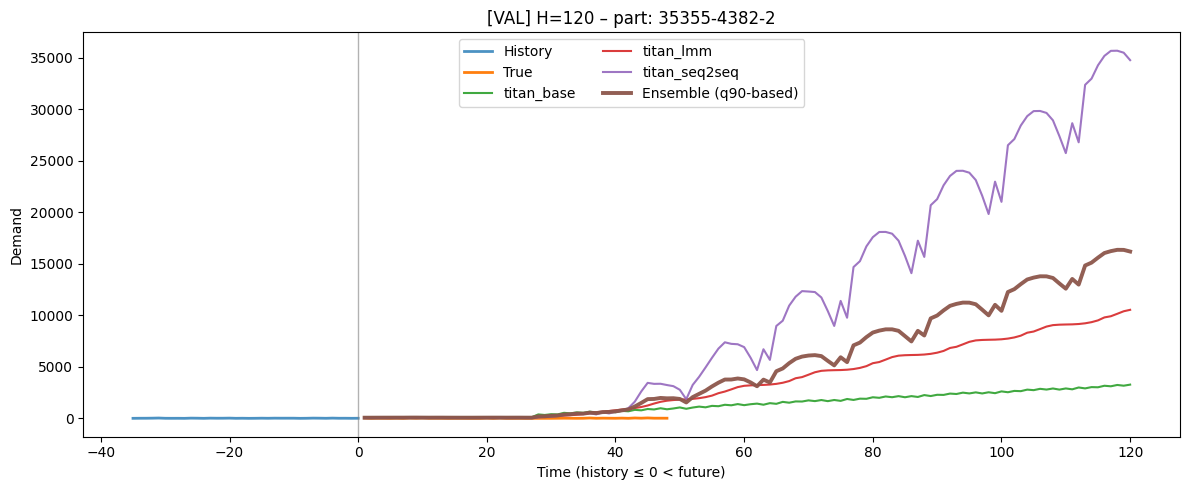

[FCAST-DBG] DMS block: Hm=27, var(Hm)=20.34, first5=[179.041, 182.742, 187.504, 193.168, 194.102]
[FCAST-DBG] DONE: H=120, var=1.14665e+06, first5=[179.041, 182.742, 187.504, 193.168, 194.102]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=19.2816, first5=[96.8729, 100.889, 105.452, 104.759, 102.713]
[FCAST-DBG] DONE: H=120, var=1.2499e+07, first5=[96.8729, 100.889, 105.452, 104.759, 102.713]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=31.6967, first5=[93.3969, 93.3133, 95.1977, 96.9233, 101.168]
[FCAST-DBG] DONE: H=120, var=1.30989e+08, first5=[93.3969, 93.3133, 95.1977, 96.9233, 101.168]
dict_items([('titan_base', array([ 179.04057,  182.74185,  187.50432,  193.16803,  194.10158,
        190.24596,  184.90399,  200.77705,  199.25069,  192.5183 ,
        185.7593 ,  185.27986,  190.4045 ,  189.69688,  188.64554,
        188.56012,  190.75401,  189.94402,  191.05385,  188.95734,
        191.36713,  191.68   ,  185.94308,  184.82388,  190.24516,
        189.55066,  189.2601 ,  562.20654,  440.94583,  

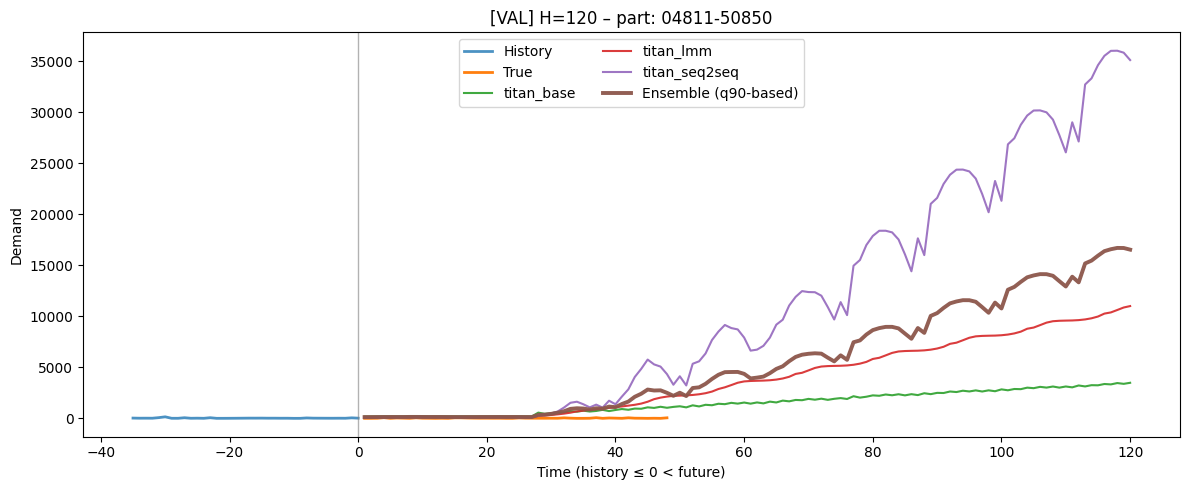

[FCAST-DBG] DMS block: Hm=27, var(Hm)=7.52567, first5=[104.598, 105.836, 107.758, 110.825, 109.897]
[FCAST-DBG] DONE: H=120, var=1.04895e+06, first5=[104.598, 105.836, 107.758, 110.825, 109.897]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=11.474, first5=[42.1676, 44.1361, 45.8276, 45.3895, 44.3956]
[FCAST-DBG] DONE: H=120, var=1.15432e+07, first5=[42.1676, 44.1361, 45.8276, 45.3895, 44.3956]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=16.5018, first5=[28.65, 28.7523, 30.8842, 32.6854, 37.0324]
[FCAST-DBG] DONE: H=120, var=1.39973e+08, first5=[28.65, 28.7523, 30.8842, 32.6854, 37.0324]
dict_items([('titan_base', array([ 104.59841 ,  105.83579 ,  107.758385,  110.82534 ,  109.89674 ,
        106.448814,  103.38638 ,  114.499054,  115.229965,  111.90244 ,
        109.9141  ,  109.99582 ,  110.25325 ,  109.054535,  107.42868 ,
        106.28461 ,  106.367584,  106.294815,  107.06145 ,  107.47084 ,
        110.49193 ,  111.3913  ,  110.06923 ,  109.769226,  110.003296,
        108.98071 ,  107.80859 , 

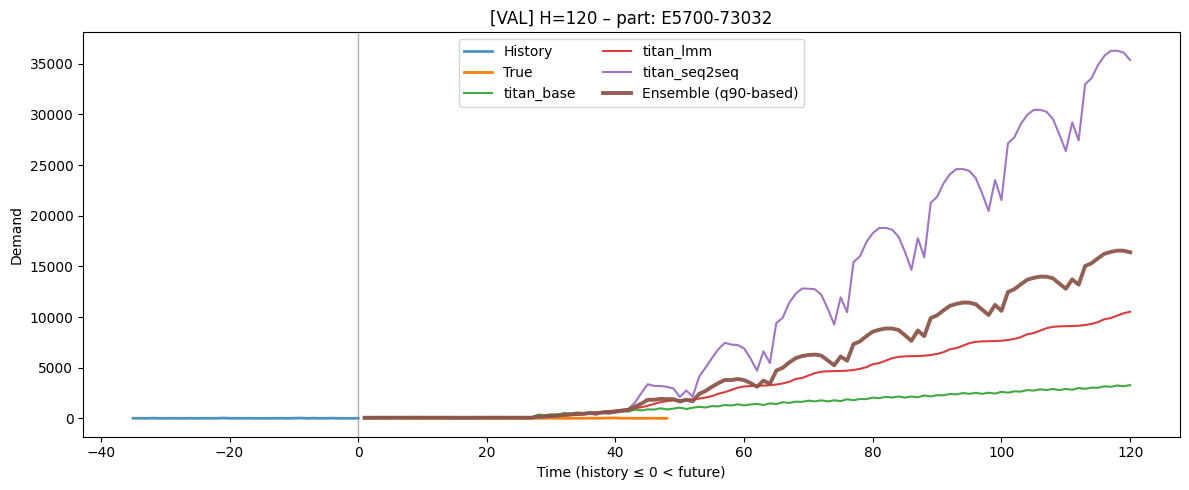

[FCAST-DBG] DMS block: Hm=27, var(Hm)=18.7065, first5=[161.76, 165.138, 169.63, 175.092, 175.873]
[FCAST-DBG] DONE: H=120, var=1.02774e+06, first5=[161.76, 165.138, 169.63, 175.092, 175.873]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=16.357, first5=[73.607, 76.766, 80.2608, 79.4817, 77.6996]
[FCAST-DBG] DONE: H=120, var=1.21067e+07, first5=[73.607, 76.766, 80.2608, 79.4817, 77.6996]
[FCAST-DBG] DMS block: Hm=27, var(Hm)=22.7899, first5=[68.7063, 68.6271, 70.5404, 72.2843, 76.4556]
[FCAST-DBG] DONE: H=120, var=1.51646e+08, first5=[68.7063, 68.6271, 70.5404, 72.2843, 76.4556]
dict_items([('titan_base', array([ 161.76   ,  165.13766,  169.63   ,  175.09238,  175.87277,
        171.79494,  166.22949,  182.6097 ,  181.58759,  175.27817,
        169.19981,  168.6804 ,  172.60716,  171.75938,  170.57513,
        170.28175,  172.22067,  171.4989 ,  172.4959 ,  171.05864,
        174.03148,  174.48293,  169.4097 ,  168.27628,  172.42186,
        171.62593,  171.15492,  526.48755,  415.41608,  481.77

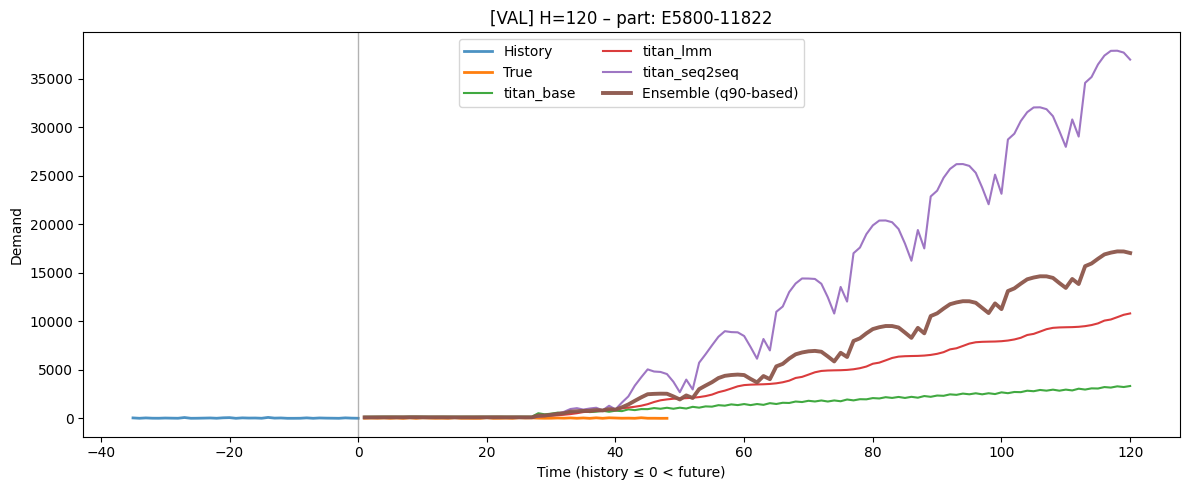

In [8]:
%load_ext autoreload
%autoreload 2

import importlib, modeling_module.utils.plot_utils as pu
import modeling_module.training.forecaster as fo
importlib.reload(pu)
importlib.reload(fo)

def my_exo_cb(start_idx: int, Hm: int, device="cuda" if torch.cuda.is_available() else "cpu"):
    # exo_dim = 2 (sin, cos)
    return fo.make_calendar_exo(start_idx, Hm, period=12, device=device)

pu.plot_120m(
    models=loaded,           # {"PatchMixer": pm_model, "Titan": ti_model, ...}
    loader=val_loader,       # (xb, yb[, part_ids])
    device="cuda" if torch.cuda.is_available() else "cpu",
    mode="val",              # ← 검증 모드
    max_plots=5,
    out_dir=None,
    show=True,
    future_exo_cb=my_exo_cb
)